In [7]:
import sys
import os 
import numpy as np
from tqdm import tqdm
import jax.numpy as jnp
import matplotlib.pyplot as plt 
from diffrax import diffeqsolve, Dopri5, ODETerm, SaveAt, PIDController, Kvaerno3, Tsit5
import diffrax

sys.path.append(os.getcwd()) 
import meanfield.hebbian_meanfield as mf


In [12]:
figdir = '/mnt/home/awakhloo/ceph/persistent-oscillations/figs'

In [2]:
def dxdt(t, x, J, A, omega, I, N, input_fn, phi=jnp.tanh):
    return (J+A)@phi(x)-x + input_fn(t)
    
def dadt(t,A, x, k, p, N, t_freeze, phi=jnp.tanh): 
    return jnp.where(t<t_freeze,
                     1/p * (k/N * jnp.outer(phi(x),phi(x)) - A),
                     0.)

def dfdt(t, Y, input_fn, N, J, omega, I, k, p, t_freeze, **kwargs): 
    x, A = Y[0:N], Y[N:N**2+N].reshape(N,N)
    xdiff = dxdt(t, x, J, A, omega, I, N, input_fn)
    adiff = dadt(t, A, x, k, p, N, t_freeze).reshape(N**2) 
    return jnp.concatenate([xdiff, adiff]) 


In [3]:
N = 1000 
g = 1.3
I = 1
f = 0.05
k = 3
Nsave=50
p = 25
phi = jnp.tanh
omega = 2*np.pi*f

T = 3000 
halt_time = 2/30 
halt = halt_time* T
t_freeze = halt 
dt_eval = 0.1
dt=0.1
A_times = np.array([T*halt_time])
tvec_eval = np.linspace(0,T,int(T/dt_eval),endpoint=False)

rtol,atol=1e-6,1e-6
# window
w = 400
skip = 50
nrep = 10

params = {
          'g' : g, 'I' : I, 'f' : f, 'k' : k, 
          'p' : p, 'omega' : omega,
          'T' : T, 'halt_time' : halt_time, 
        'halt' : T * halt_time,
         }



max_steps = 12000

In [4]:
lifetimes = [] 

for i in tqdm(range(nrep)):
    params['Y0'] = np.concatenate([np.random.randn(N), 
                               np.zeros(N**2)])
    params['J'] = np.random.randn(N,N) * g/np.sqrt(N) 
    params['t_freeze'] = t_freeze
    thetas = np.random.uniform(low=0,high=2*np.pi,size=(N,))
    inp_fn = lambda t : mf.halted_inps(t, thetas, I, omega, halt) 
    ode = lambda t,y, args : dfdt(t,y,inp_fn,N,**params) 
    ss =  [diffrax.SubSaveAt(ts=np.linspace(0,T,int(T/dt_eval)), fn=lambda t,x,args : x[:Nsave])]
    asave = diffrax.SubSaveAt(ts=A_times, fn=lambda t,x,args : x[N:].reshape(N,N),)
    ss.append(asave) 
    saveat = diffrax.SaveAt(subs=ss)
    term = ODETerm(ode)
    solver=Tsit5()
    stepsize_controller = PIDController(rtol=rtol, atol=atol)
    # solve
    sol = diffeqsolve(term, solver, t0=0, t1=T, dt0=0.1, y0=params['Y0'], saveat=saveat,
                  stepsize_controller=stepsize_controller, max_steps=max_steps)
    Xh, A = sol.ys
    life = mf.get_lifetime(Xh, T, dt, halt_time, w=w, skip=skip)
    lifetimes.append(life)

100%|██████████| 10/10 [06:38<00:00, 39.82s/it]


In [5]:
def plot_with_middle_cut(ax_left, ax_right, t, x, L,
                         d=0.015, lw=1, color='k',
                         plot_kwargs=None,
                         hide_inner_spines=True,
                         sharey_cosmetics=True):
    if plot_kwargs is None:
        plot_kwargs = {}

    # Plot full data on both (simple & robust)
    ax_left.plot(t, x, **plot_kwargs)
    ax_right.plot(t, x, **plot_kwargs)

    # Set x-limits to show only the ends
    ax_left.set_xlim(t[0], t[L-1])
    ax_right.set_xlim(t[-L], t[-1])

    if hide_inner_spines:
        ax_left.spines['right'].set_visible(False)
        ax_right.spines['left'].set_visible(False)

    if sharey_cosmetics:
        # Common broken-axis tick conventions
        ax_right.yaxis.tick_right()
        ax_right.tick_params(labelright=False)  # keep labels only on left
        ax_left.yaxis.tick_left()

    # Break marks: two diagonals on each inner edge
    kwL = dict(transform=ax_left.transAxes, color=color, clip_on=False, lw=lw)
    ax_left.plot((1-d, 1+d), (-d, +d), **kwL)
    ax_left.plot((1-d, 1+d), (1-d, 1+d), **kwL)

    kwR = dict(transform=ax_right.transAxes, color=color, clip_on=False, lw=lw)
    ax_right.plot((-d, +d), (-d, +d), **kwR)
    ax_right.plot((-d, +d), (1-d, 1+d), **kwR)

    return ax_left, ax_right

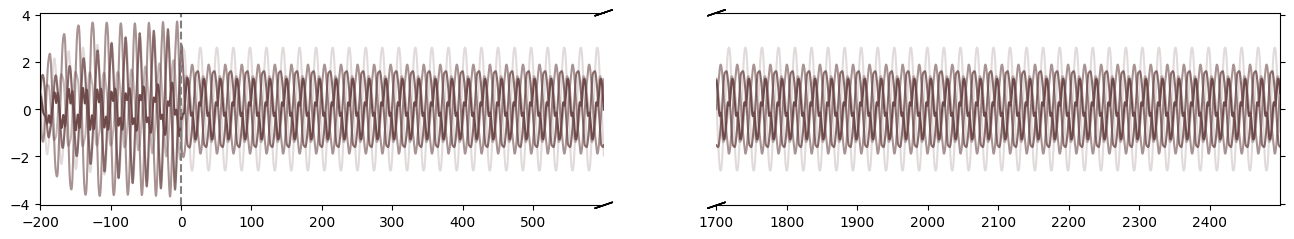

In [15]:
# fig, ax = plt.subplots(1,3,figsize=(16,4),width_ratios=[1.95,1.95, 1])
fig, ax = plt.subplots(1,2,figsize=(16,2.5))

lim = int(300/dt)
fn=22
b = 7

c = '#6E4A4A' # '#A27676' #'rosybrown' 
nplt=5
# inds = np.random.randint(low=0, high=Nsave, size=nplt)
inds = [35, 19,  3, 13, 36]
for i in range(nplt): 
    plot_with_middle_cut(ax[0], ax[1], 
                         (tvec_eval-halt)[:-lim], 
                         Xh[:-lim,inds[i]], int(800/dt),
                        plot_kwargs={'alpha' : 0.2*(i+1),
                                    'color' : c})

ylim=ax[1].get_ylim()
ax[0].vlines(0, ylim[0],ylim[1], ls='--', color='grey')
ax[0].set_ylim(ylim)

# ax[1].set_xlabel("t", fontsize=fn)
ax[1].xaxis.set_label_coords(-0.12, -0.12)      # x=0 is left edge of the axes; y<0 pushes it down
ax[1].xaxis.label.set_horizontalalignment('left')
# ax[0].set_ylabel("x(t)", fontsize=fn)

s=15


fig.savefig(figdir + '/sm_figs/freeze_chaos.png', dpi=300, bbox_inches='tight')

In [11]:
inds

array([35, 19,  3, 13, 36])